<a href="https://www.kaggle.com/code/sonawanelalitsunil/resume-job-description-matching-ml?scriptVersionId=258524017" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/resume-vs-job-description-matching-dataset/resume_job_matching_dataset.csv


## Title: Resume–Job Description Matching Dataset

## Description (detailed):
This dataset is designed for tasks involving resume–job description similarity and matching. It contains pairs of resumes and job descriptions with associated labels indicating whether the candidate profile is a good fit for the job. The dataset can be used to train and evaluate models for recruitment automation, candidate ranking, recommendation systems, and natural language processing (NLP) tasks such as semantic similarity, information retrieval, and text classification.

It typically includes:

Resume text – candidate skills, experience, education, and achievements.

Job description text – required skills, qualifications, and role responsibilities.

Match labels or scores – binary (match/no-match) or numerical (degree of match).

This resource is valuable for building machine learning models that automate resume screening, improve candidate-job alignment, and reduce recruitment bias.

## Import dataset

In [2]:
df = pd.read_csv("/kaggle/input/resume-vs-job-description-matching-dataset/resume_job_matching_dataset.csv")

In [3]:
df.head()

,job_description,resume,match_score
0,"Data Analyst needed with experience in SQL, Ex...","Experienced professional skilled in SQL, Power...",4
1,Data Scientist needed with experience in Stati...,"Experienced professional skilled in Python, De...",4
2,Software Engineer needed with experience in Sy...,"Experienced professional skilled in wait, Git,...",5
3,"ML Engineer needed with experience in Python, ...","Experienced professional skilled in return, De...",4
4,Software Engineer needed with experience in RE...,"Experienced professional skilled in REST APIs,...",5


In [4]:
df.tail()

,job_description,resume,match_score
9995,Product Manager needed with experience in Scru...,Experienced professional skilled in commercial...,4
9996,Data Analyst needed with experience in Tableau...,"Experienced professional skilled in financial,...",2
9997,Product Manager needed with experience in Prod...,Experienced professional skilled in internatio...,2
9998,Product Manager needed with experience in Agil...,"Experienced professional skilled in role, Agil...",2
9999,"Data Scientist needed with experience in NLP, ...",Experienced professional skilled in Machine Le...,3


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   job_description  10000 non-null  object
 1   resume           10000 non-null  object
 2   match_score      10000 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 234.5+ KB


In [6]:
df.describe()

,match_score
count,10000.00000
mean,3.50030
std,1.16899
min,1.00000
25%,3.00000
50%,4.00000
75%,4.00000
max,5.00000


In [7]:
df.isnull().sum()

job_description    0
resume             0
match_score        0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.shape

(10000, 3)

In [10]:
df.dtypes

job_description    object
resume             object
match_score         int64
dtype: object

In [11]:
df.columns

Index(['job_description', 'resume', 'match_score'], dtype='object')

## Data visualizations

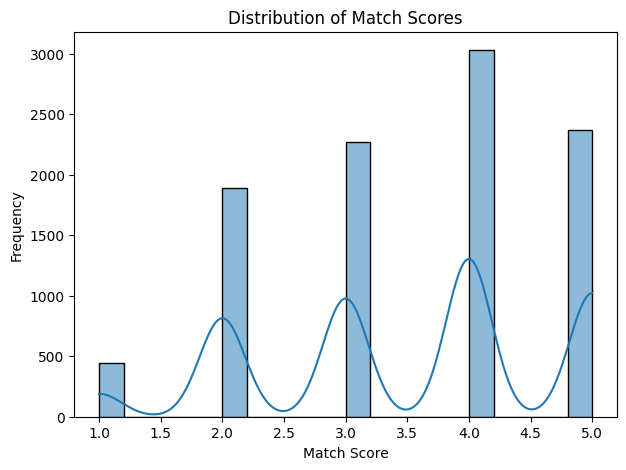

In [12]:
plt.figure(figsize=(7,5))
sns.histplot(df['match_score'], bins=20, kde=True)
plt.title("Distribution of Match Scores")
plt.xlabel("Match Score")
plt.ylabel("Frequency")
plt.show()


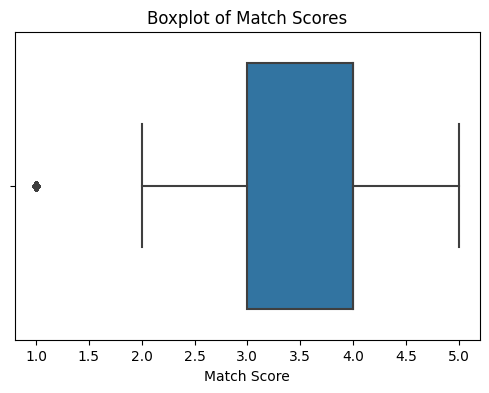

In [13]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['match_score'])
plt.title("Boxplot of Match Scores")
plt.xlabel("Match Score")
plt.show()


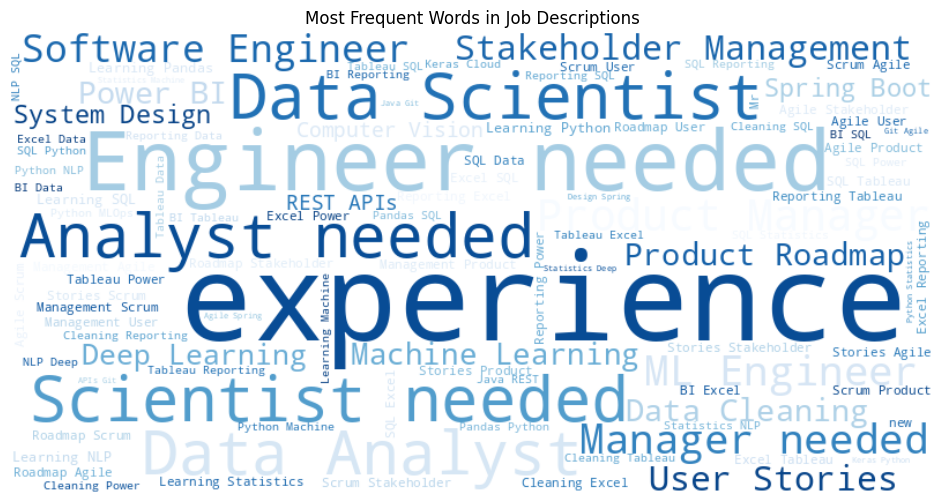

In [14]:
from wordcloud import WordCloud, STOPWORDS
job_text = " ".join(df['job_description'].astype(str))
wordcloud = WordCloud(stopwords=STOPWORDS, background_color="white", colormap="Blues",
                      max_words=100, width=800, height=400).generate(job_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Most Frequent Words in Job Descriptions")
plt.show()


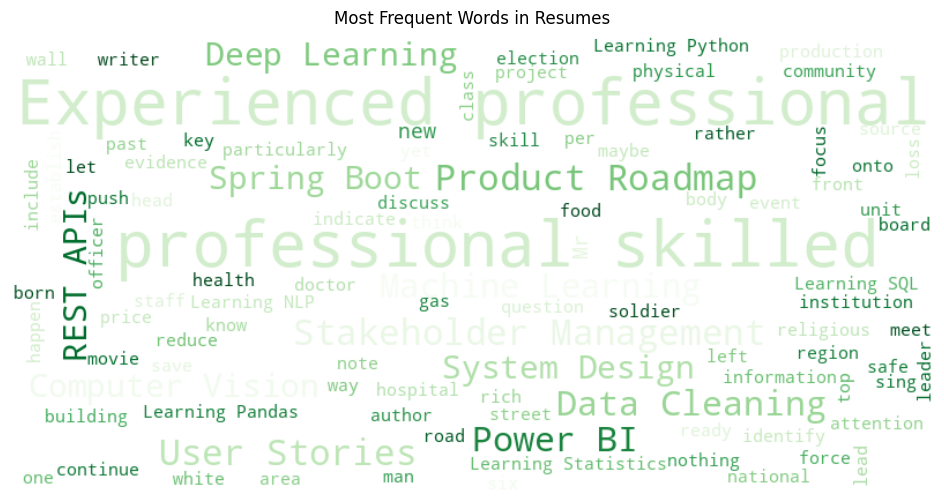

In [15]:
resume_text = " ".join(df['resume'].astype(str))
wordcloud = WordCloud(stopwords=STOPWORDS, background_color="white", colormap="Greens",
                      max_words=100, width=800, height=400).generate(resume_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Most Frequent Words in Resumes")
plt.show()


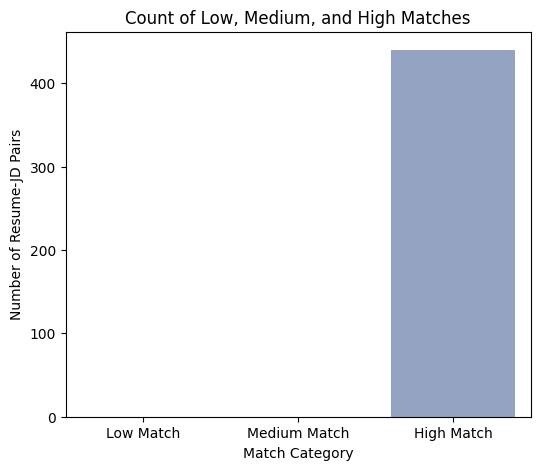

In [16]:
# Create categories
df['score_category'] = pd.cut(df['match_score'],
                              bins=[0, 0.4, 0.7, 1.0],
                              labels=['Low Match','Medium Match','High Match'])

plt.figure(figsize=(6,5))
sns.countplot(data=df, x='score_category', palette="Set2")
plt.title("Count of Low, Medium, and High Matches")
plt.xlabel("Match Category")
plt.ylabel("Number of Resume-JD Pairs")
plt.show()


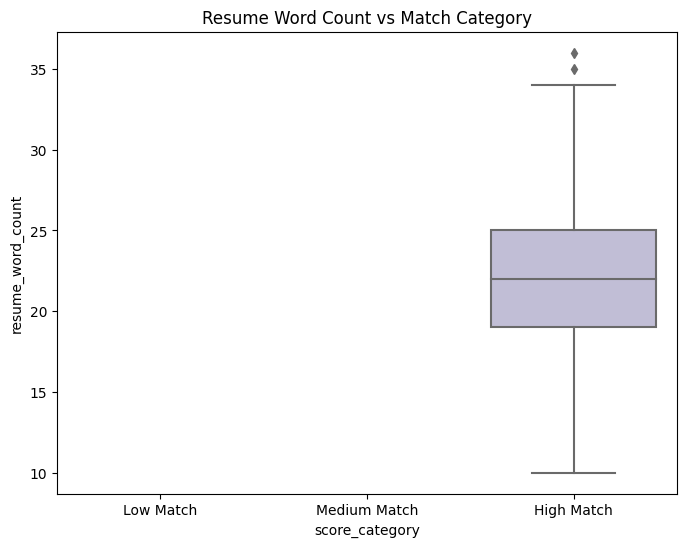

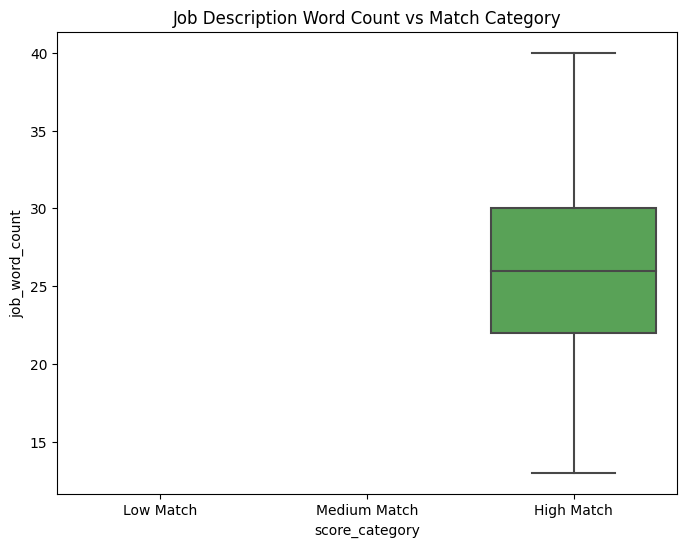

In [17]:
df['resume_word_count'] = df['resume'].astype(str).apply(lambda x: len(x.split()))
df['job_word_count'] = df['job_description'].astype(str).apply(lambda x: len(x.split()))

plt.figure(figsize=(8,6))
sns.boxplot(data=df, x='score_category', y='resume_word_count', palette="Set3")
plt.title("Resume Word Count vs Match Category")
plt.show()

plt.figure(figsize=(8,6))
sns.boxplot(data=df, x='score_category', y='job_word_count', palette="Set1")
plt.title("Job Description Word Count vs Match Category")
plt.show()


## Predictive modeling

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from xgboost import XGBClassifier

In [19]:
df['score_category'] = pd.cut(df['match_score'],
                              bins=[0, 0.4, 0.7, 1.0],
                              labels=['Low', 'Medium', 'High'])
le = LabelEncoder()
df['score_category'] = le.fit_transform(df['score_category'])
df['text'] = df['job_description'].astype(str) + " " + df['resume'].astype(str)
tfidf = TfidfVectorizer(max_features=5000, stop_words='english')
X = tfidf.fit_transform(df['text']).toarray()
y = df['score_category']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [20]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(),
    "Naive Bayes": MultinomialNB(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
}


In [21]:
results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds) * 100
    results.append([name, acc])

In [22]:
results_df = pd.DataFrame(results, columns=["Algorithm", "Accuracy (%)"])
print(results_df)

             Algorithm  Accuracy (%)
0  Logistic Regression         95.60
1        Decision Tree         94.00
2        Random Forest         95.60
3    Gradient Boosting         95.50
4                  KNN         95.60
5                  SVM         95.60
6          Naive Bayes         95.60
7              XGBoost         98.25


## Thank you...pls upvote!!!!